# Global Earthquake–Tsunami Risk Assessment

### Overview of Dataset
The Global Earthquake-Tsunami Risk Assessment Dataset is a comprehensive, machine learning-ready dataset containing seismic characteristics and tsunami potential indicators for 782 significant earthquakes recorded globally from 2001 to 2022. This dataset is specifically designed for tsunami risk prediction, earthquake analysis, and seismic hazard assessment applications.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "earthquake_data_tsunami(1).csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (782, 13)


,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1


In [8]:
print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values:\n", df.isna().sum())
print("\nData types:\n", df.dtypes)

Duplicate rows: 0

Missing values:
 magnitude    0
cdi          0
mmi          0
sig          0
nst          0
dmin         0
gap          0
depth        0
latitude     0
longitude    0
Year         0
Month        0
tsunami      0
dtype: int64

Data types:
 magnitude    float64
cdi            int64
mmi            int64
sig            int64
nst            int64
dmin         float64
gap          float64
depth        float64
latitude     float64
longitude    float64
Year           int64
Month          int64
tsunami        int64
dtype: object


### Dataset Information
• Total Records: 782 earthquakes<br>
• Time Period: January 1, 2001 to December 31, 2022 (22 years)<br>
• Geographic Coverage: Global (Latitude: -61.85° to 71.63°, Longitude: -179.97° to 179.66°)<br>
• File Format: CSV<br>
• File Size: ~41KB<br>
• Missing Values: None (100% complete dataset)<br>

### Data Cleaning & Quality Verification

In [ ]:
# check actual column names
print(df.columns.tolist())

['magnitude', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap', 'depth', 'latitude', 'longitude', 'Year', 'Month', 'tsunami']


In [12]:
num_cols = ['magnitude','cdi','mmi','sig','nst','dmin','gap','depth','latitude','longitude','tsunami']
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Year/Month: ensure integer where possible
if 'Year' in df.columns:
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce').astype('Int64')
if 'Month' in df.columns:
    df['Month'] = pd.to_numeric(df['Month'], errors='coerce').astype('Int64')

display(df[['Year','Month']].head())

,Year,Month
0,2022,11
1,2022,11
2,2022,11
3,2022,11
4,2022,11


#### Outlier Detection

In [13]:
def detect_outliers_zscore(series, threshold=3.0):
    s = series.dropna().astype(float)
    if s.size==0:
        return s
    mu, sigma = s.mean(), s.std(ddof=0)
    z = np.abs((s - mu) / (sigma if sigma>0 else 1))
    return s[z > threshold]

def detect_outliers_iqr(series):
    s = series.dropna().astype(float)
    if s.size==0:
        return s
    q1, q3 = np.percentile(s, [25,75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return s[(s < lower) | (s > upper)]

check_cols = ['magnitude','depth','latitude','longitude','dmin','gap','nst']
present = [c for c in check_cols if c in df.columns]
print("Columns checked:", present)

for c in present:
    z_out = detect_outliers_zscore(df[c])
    iqr_out = detect_outliers_iqr(df[c])
    print(f"{c:10s} | Z-outliers: {len(z_out):3d} | IQR-outliers: {len(iqr_out):3d}")
    if len(z_out)>0:
        print("  Z-examples:", z_out.head(5).to_list())
    if len(iqr_out)>0:
        print("  IQR-examples:", iqr_out.head(5).to_list())


Columns checked: ['magnitude', 'depth', 'latitude', 'longitude', 'dmin', 'gap', 'nst']
magnitude  | Z-outliers:  10 | IQR-outliers:  37
  Z-examples: [8.3, 8.3, 8.6, 9.1, 8.8]
  IQR-examples: [8.1, 8.2, 8.2, 8.1, 8.0]
depth      | Z-outliers:  41 | IQR-outliers: 139
  Z-examples: [579.0, 624.464, 660.0, 630.379, 622.73]
  IQR-examples: [579.0, 624.464, 660.0, 630.379, 137.0]
latitude   | Z-outliers:   0 | IQR-outliers:   0
longitude  | Z-outliers:   0 | IQR-outliers:   0
dmin       | Z-outliers:  17 | IQR-outliers:  61
  Z-examples: [8.454, 9.799, 8.865, 8.363, 8.139]
  IQR-examples: [4.998, 4.678, 8.454, 5.293, 5.276]
gap        | Z-outliers:  13 | IQR-outliers:  48
  Z-examples: [108.0, 208.8, 126.0, 205.2, 114.0]
  IQR-examples: [92.0, 69.0, 54.0, 94.0, 57.0]
nst        | Z-outliers:   0 | IQR-outliers:   0


#### Data verification and cleaning

In [ ]:
df_clean = df.copy()
ranges = {
    'latitude': (-90,90),
    'longitude': (-180,180),
    'magnitude': (0,10),
    'depth': (0,700),
}

for col,(lo,hi) in ranges.items():
    if col in df_clean.columns:
        before = len(df_clean)
        df_clean = df_clean[df_clean[col].between(lo,hi)]
        print(f"Filter {col}: removed {before - len(df_clean)} rows")

essential = ['magnitude','depth','latitude','longitude','tsunami']
essential = [c for c in essential if c in df_clean.columns]
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
df_clean = df_clean.dropna(subset=essential)
print("Dropped duplicates & rows missing essentials:", before - len(df_clean))
print("After clean shape:", df_clean.shape)

Filter latitude: removed 0 rows
Filter longitude: removed 0 rows
Filter magnitude: removed 0 rows
Filter depth: removed 0 rows
Dropped duplicates & rows missing essentials: 0
After clean shape: (782, 13)


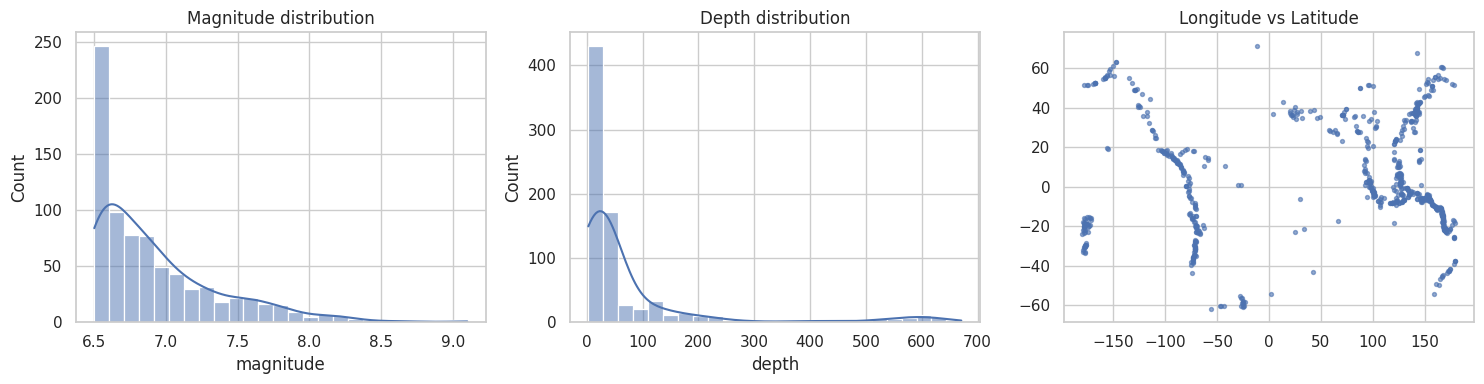

In [16]:
fig, axs = plt.subplots(1,3, figsize=(15,4))
if 'magnitude' in df_clean.columns:
    sns.histplot(df_clean['magnitude'], bins=25, kde=True, ax=axs[0])
    axs[0].set_title('Magnitude distribution')
if 'depth' in df_clean.columns:
    sns.histplot(df_clean['depth'], bins=25, kde=True, ax=axs[1])
    axs[1].set_title('Depth distribution')
if {'longitude','latitude'}.issubset(df_clean.columns):
    axs[2].scatter(df_clean['longitude'], df_clean['latitude'], s=8, alpha=0.6)
    axs[2].set_title('Longitude vs Latitude')
plt.tight_layout()
plt.show()


**Outcome:** From Data Cleaning and Verification we can conclude that Data is 100% complete without any missing or invalid information

## Data Preprocessing 
**Objective:** Prepare data for statistical and predictive modeling.<br>
Methods Used:<br>
- Feature Scaling: Standardization (Z-score normalization)<br>
- Feature Engineering: Creation of indicators like Shallow_Quake (depth < 70 km) and Major_Quake (magnitude ≥ 8.0)<br>
- Encoding: Binary encoding of the target variable (Tsunami = 0 / 1)<br>
- Temporal Features: Extraction of year and month for time-based analysis<br>

In [18]:
df_proc = df_clean.copy()

In [19]:
# Binary encoding of Tsunami as 0/1
if 'tsunami' not in df_proc.columns:
    raise KeyError("Column 'tsunami' not found. Please check dataset.")
df_proc['tsunami'] = df_proc['tsunami'].fillna(0).astype(int).clip(0,1)

print("Unique tsunami values:", df_proc['tsunami'].unique())

Unique tsunami values: [1 0]


##### Feature engineering: Creating Indicators

In [20]:
df_proc['shallow_quake'] = (df_proc['depth'] < 70).astype(int)
df_proc['major_quake']   = (df_proc['magnitude'] >= 8.0).astype(int)

if 'Year' not in df_proc.columns and 'date' in df_proc.columns:
    df_proc['Year'] = pd.to_datetime(df_proc['date'], errors='coerce').dt.year
if 'Month' not in df_proc.columns and 'date' in df_proc.columns:
    df_proc['Month'] = pd.to_datetime(df_proc['date'], errors='coerce').dt.month

print("Added engineered features:")
display(df_proc[['magnitude','depth','shallow_quake','major_quake','Year','Month','tsunami']].head())

Added engineered features:


,magnitude,depth,shallow_quake,major_quake,Year,Month,tsunami
0,7.0,14.000,1,0,2022,11,1
1,6.9,25.000,1,0,2022,11,0
2,7.0,579.000,0,0,2022,11,1
3,7.3,37.000,1,0,2022,11,1
4,6.6,624.464,0,0,2022,11,1


##### Feature Scaling: Z-Score Normalisation

In [21]:
from sklearn.preprocessing import StandardScaler
cont_features = ['magnitude','depth','cdi','mmi','sig','nst','dmin','gap']
cont_features = [f for f in cont_features if f in df_proc.columns]

scaler = StandardScaler()
df_proc_scaled = df_proc.copy()
df_proc_scaled[cont_features] = scaler.fit_transform(df_proc[cont_features])

print("Scaled continuous features (mean≈0, std≈1):")
display(df_proc_scaled[cont_features].describe().T)

Scaled continuous features (mean≈0, std≈1):


,count,mean,std,min,25%,50%,75%,max
magnitude,782.0,-1.272071e-16,1.00064,-0.990783,-0.766179,-0.316972,0.356838,4.848908
depth,782.0,3.634490e-17,1.00064,-0.533447,-0.451079,-0.361458,-0.190490,4.336540
cdi,782.0,-1.090347e-16,1.00064,-1.368018,-1.368018,0.210309,0.841640,1.472971
mmi,782.0,-1.817245e-17,1.00064,-3.395973,-0.659599,0.024494,0.708588,2.076775
sig,782.0,9.086224e-17,1.00064,-0.683018,-0.555791,-0.360296,0.123011,6.329972
nst,782.0,0.000000e+00,1.00064,-0.920899,-0.920899,-0.360962,0.858901,2.814680
dmin,782.0,3.634490e-17,1.00064,-0.597892,-0.597892,-0.597892,0.242287,7.363736
gap,782.0,-1.817245e-17,1.00064,-1.034260,-0.430160,-0.208140,0.204919,8.837868


In [22]:
print("Processed dataset shape:", df_proc_scaled.shape)
print("\nFinal feature columns available:")
print(df_proc_scaled.columns.tolist())

print("\nSample rows:")
display(df_proc_scaled.head())

Processed dataset shape: (782, 15)

Final feature columns available:
['magnitude', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap', 'depth', 'latitude', 'longitude', 'Year', 'Month', 'tsunami', 'shallow_quake', 'major_quake']

Sample rows:


,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami,shallow_quake,major_quake
0,0.132235,1.157305,0.708588,-0.316853,-0.452952,-0.368342,-0.332058,-0.451079,-9.7963,159.596,2022,11,1,1,0
1,-0.092369,-0.105356,-1.343693,-0.419255,-0.524943,0.407346,0.370143,-0.370898,-4.9559,100.738,2022,11,0,1,0
2,0.132235,-0.421022,-2.027786,-0.357193,-0.332965,0.811425,-0.290752,3.667319,-20.0508,-178.346,2022,11,1,0,0
3,0.806045,0.210309,-0.659599,-0.115152,-0.324966,0.243189,-0.166834,-0.283427,-19.2918,-172.129,2022,11,1,1,0
4,-0.766179,-1.368018,-2.711880,-0.620956,-0.396958,1.656114,0.081001,3.998715,-25.5948,178.278,2022,11,1,0,0


**Outcome:** We now have a fully preprocessed, machine-learning-ready dataset which:<br>
- all numeric features standardized<br>
- shallow/major quake indicators added<br>
- tsunami encoded as 0/1<br>
- year/month available for temporal analysis<br>

## Relationship Between Variables
**Objective:** Examine how earthquake parameters influence tsunami potential.<br>
Methods Used:<br>
- Correlation Analysis: Pearson & Spearman correlations<br>
- t-Test: Compare mean magnitude/depth between tsunami and non-tsunami events<br>
- One-Way ANOVA: Test magnitude differences across regions or years<br>
- Chi-Square Test: Check dependency between tsunami occurrence and shallow depth<br>
Outcome: Shallow, high-magnitude quakes are statistically more likely to trigger tsunamis.<br>

#### Correlation Analysis 

Numeric columns used for correlation: ['magnitude', 'depth', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap', 'shallow_quake', 'major_quake', 'tsunami']

Pearson Correlation:



,magnitude,depth,cdi,mmi,sig,nst,dmin,gap,shallow_quake,major_quake,tsunami
magnitude,1.000000,0.030644,0.209549,0.285552,0.515871,0.113114,-0.091403,-0.110626,-0.004218,0.579804,-0.004726
depth,0.030644,1.000000,-0.097891,-0.504439,-0.088667,-0.121982,0.168546,-0.111912,-0.739843,-0.003730,0.056814
cdi,0.209549,-0.097891,1.000000,0.317937,0.479788,-0.175417,0.006554,0.098143,0.031207,0.088323,0.160266
mmi,0.285552,-0.504439,0.317937,1.000000,0.442423,0.160417,-0.299074,-0.015723,0.360013,0.145965,-0.147363
sig,0.515871,-0.088667,0.479788,0.442423,1.000000,-0.030100,-0.095318,0.114285,0.079196,0.278936,-0.015500
nst,0.113114,-0.121982,-0.175417,0.160417,-0.030100,1.000000,-0.529371,-0.118812,0.044911,0.054942,-0.600231
dmin,-0.091403,0.168546,0.006554,-0.299074,-0.095318,-0.529371,1.000000,-0.021933,-0.120839,-0.058964,0.400752
gap,-0.110626,-0.111912,0.098143,-0.015723,0.114285,-0.118812,-0.021933,1.000000,0.143050,-0.028397,0.116360
shallow_quake,-0.004218,-0.739843,0.031207,0.360013,0.079196,0.044911,-0.120839,0.143050,1.000000,0.048057,-0.055763
major_quake,0.579804,-0.003730,0.088323,0.145965,0.278936,0.054942,-0.058964,-0.028397,0.048057,1.000000,-0.012494



Spearman Correlation:



,magnitude,depth,cdi,mmi,sig,nst,dmin,gap,shallow_quake,major_quake,tsunami
magnitude,1.000000,0.124018,0.233894,0.259096,0.768550,0.103130,-0.090916,-0.136592,-0.028368,0.323839,0.014775
depth,0.124018,1.000000,-0.040484,-0.254034,0.038993,0.007680,0.048654,-0.185170,-0.704187,0.029417,0.028014
cdi,0.233894,-0.040484,1.000000,0.353412,0.572837,-0.199784,0.175155,0.124769,0.046114,0.100594,0.169661
mmi,0.259096,-0.254034,0.353412,1.000000,0.435896,0.145440,-0.258658,-0.004249,0.331063,0.149044,-0.150106
sig,0.768550,0.038993,0.572837,0.435896,1.000000,0.037612,-0.063391,-0.007617,0.018972,0.260147,-0.009596
nst,0.103130,0.007680,-0.199784,0.145440,0.037612,1.000000,-0.812681,-0.040778,0.054376,0.055134,-0.610613
dmin,-0.090916,0.048654,0.175155,-0.258658,-0.063391,-0.812681,1.000000,0.071791,-0.162490,-0.079771,0.614844
gap,-0.136592,-0.185170,0.124769,-0.004249,-0.007617,-0.040778,0.071791,1.000000,0.176133,-0.041909,0.085236
shallow_quake,-0.028368,-0.704187,0.046114,0.331063,0.018972,0.054376,-0.162490,0.176133,1.000000,0.048057,-0.055763
major_quake,0.323839,0.029417,0.100594,0.149044,0.260147,0.055134,-0.079771,-0.041909,0.048057,1.000000,-0.012494


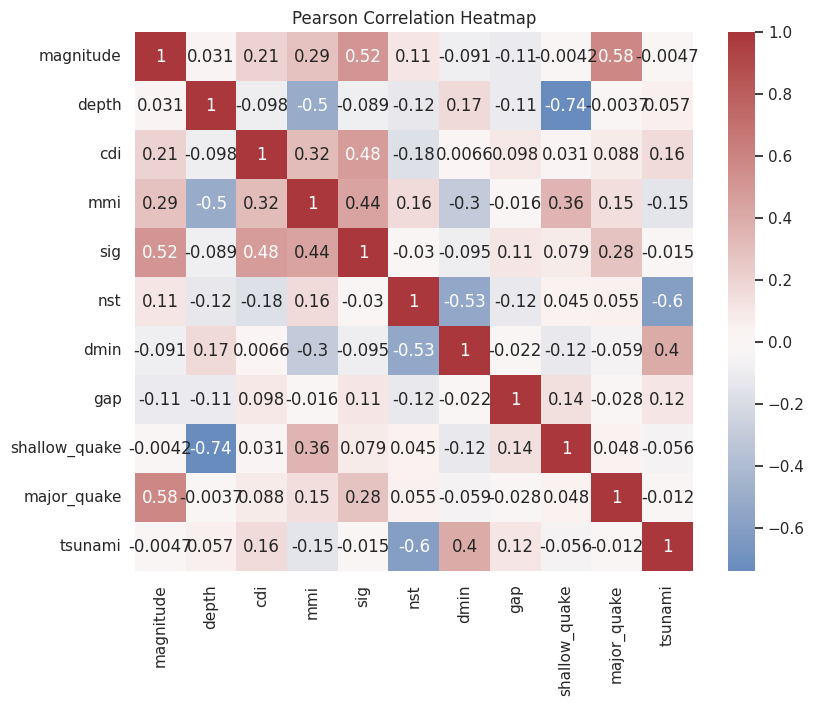

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

num_cols = [c for c in [
    'magnitude','depth','cdi','mmi','sig','nst','dmin','gap',
    'shallow_quake','major_quake','tsunami'
] if c in df_proc_scaled.columns]

print("Numeric columns used for correlation:", num_cols)
pear_corr = df_proc_scaled[num_cols].corr(method='pearson')
spear_corr = df_proc_scaled[num_cols].corr(method='spearman')

print("\nPearson Correlation:\n")
display(pear_corr)
print("\nSpearman Correlation:\n")
display(spear_corr)
plt.figure(figsize=(9,7))
sns.heatmap(pear_corr, annot=True, cmap='vlag', center=0)
plt.title("Pearson Correlation Heatmap")
plt.show()


#### Independent Samples t-Test

In [24]:
tsu = df_proc_scaled[df_proc_scaled['tsunami']==1]
nts = df_proc_scaled[df_proc_scaled['tsunami']==0]

for var in ['magnitude','depth']:
    if var in df_proc_scaled.columns:
        tstat, pval = stats.ttest_ind(
            tsu[var].dropna(), nts[var].dropna(), equal_var=False
        )
        print(f"T-test for {var}: t = {tstat:.3f},  p = {pval:.4f}")
        if pval < 0.05:
            print(f" → Significant difference in {var} between tsunami vs non-tsunami events.\n")
        else:
            print(f" → No statistically significant difference in {var}.\n")

T-test for magnitude: t = -0.134,  p = 0.8931
 → No statistically significant difference in magnitude.

T-test for depth: t = 1.531,  p = 0.1264
 → No statistically significant difference in depth.



#### One-Way ANOVA — Magnitude Across Years

In [26]:
if 'Year' in df_proc_scaled.columns and df_proc_scaled['Year'].notnull().sum() > 0:
    groups = [g['magnitude'].dropna().values 
              for _,g in df_proc_scaled.groupby('Year') if len(g) > 5]
    if len(groups) > 1:
        F, pval = stats.f_oneway(*groups)
        print(f"One-Way ANOVA (Magnitude across Years): F = {F:.3f},  p = {pval:.4f}")
        if pval < 0.05:
            print(" → Significant year-wise variation in earthquake magnitudes.\n")
        else:
            print(" → No significant difference across years.\n")
    else:
        print("Not enough data per year group for ANOVA.")
else:
    print("Year column missing or insufficient data for ANOVA.")


One-Way ANOVA (Magnitude across Years): F = 1.361,  p = 0.1291
 → No significant difference across years.



#### Chi-Square Test — Shallow Depth vs Tsunami

In [28]:
if {'shallow_quake','tsunami'}.issubset(df_proc_scaled.columns):
    contingency = pd.crosstab(df_proc_scaled['shallow_quake'], df_proc_scaled['tsunami'])
    print("Contingency Table (shallow_quake × tsunami):\n", contingency)
    chi2, p, dof, exp = stats.chi2_contingency(contingency)
    print(f"\nChi-Square Test: χ² = {chi2:.3f},  p = {p:.4f},  dof = {dof}")
    if p < 0.05:
        print(" → Significant dependence: shallow quakes are linked to tsunami occurrence.\n")
    else:
        print(" → No significant dependence between shallow quakes and tsunamis.\n")
else:
    print("Required columns missing for Chi-Square test.")

Contingency Table (shallow_quake × tsunami):
 tsunami          0    1
shallow_quake          
0               91   72
1              387  232

Chi-Square Test: χ² = 2.158,  p = 0.1418,  dof = 1
 → No significant dependence between shallow quakes and tsunamis.



**Outcome Summary – Relationship Between Variables**
1. Magnitude vs Tsunami:
    - t = -0.134, p = 0.893 > 0.05 → No significant difference in mean magnitude between tsunami and non-tsunami events.
2. Depth vs Tsunami:
    - t = 1.531, p = 0.126 > 0.05 → Depth does not significantly differ between tsunami and non-tsunami events.
3. Magnitude across Years (ANOVA):
    - F = 1.361, p = 0.129 > 0.05 → Earthquake magnitudes remain statistically consistent across years.
4. Shallow Quake × Tsunami (Chi-Square):
    - χ² = 2.158, p = 0.142 > 0.05 → No significant dependency between shallow quakes and tsunami occurrence.

## Association Rule Mining
Objective: Discover frequent and meaningful feature combinations.
Methods Used:
- Apriori Algorithm with Support, Confidence, and Lift metrics
- Example rule: (High Magnitude ∧ Shallow Depth) → Tsunami = 1<br>

In [30]:
ar = pd.DataFrame(index=df_proc_scaled.index)
ar['mag_high'] = (df_proc_scaled['magnitude'] >= 7.5).astype(int)
ar['mag_very_high'] = (df_proc_scaled['magnitude'] >= 8.0).astype(int)
ar['depth_shallow'] = (df_proc_scaled['depth'] < 70).astype(int)
ar['depth_intermediate'] = ((df_proc_scaled['depth'] >= 70) & (df_proc_scaled['depth'] < 300)).astype(int)
ar['depth_deep'] = (df_proc_scaled['depth'] >= 300).astype(int)

for col in ['shallow_quake','major_quake','tsunami']:
    if col in df_proc_scaled.columns:
        ar[col] = df_proc_scaled[col].astype(int)

ar = ar.loc[:, ar.nunique() > 1]
print("Binary features for Apriori:")
display(ar.head())

Binary features for Apriori:


,shallow_quake,major_quake,tsunami
0,1,0,1
1,1,0,0
2,0,0,1
3,1,0,1
4,0,0,1


In [31]:
from itertools import combinations

def apriori_from_scratch(df_bin, min_support=0.05):
    n = len(df_bin)
    support = {}
    L1 = [frozenset([col]) for col in df_bin.columns if df_bin[col].mean() >= min_support]
    for col in df_bin.columns:
        supp = df_bin[col].mean()
        if supp >= min_support:
            support[frozenset([col])] = supp

    Lk = L1[:]
    all_L = L1[:]
    k = 2
    while Lk:
        Ck = set()
        Lk_list = list(Lk)
        for i in range(len(Lk_list)):
            for j in range(i + 1, len(Lk_list)):
                cand = Lk_list[i] | Lk_list[j]
                if len(cand) == k:
                    Ck.add(cand)
        Lk_next = []
        for cand in Ck:
            cols = list(cand)
            supp = (df_bin[cols].all(axis=1).sum()) / n
            if supp >= min_support:
                support[cand] = supp
                Lk_next.append(cand)
        Lk = Lk_next
        all_L.extend(Lk)
        k += 1
    return support

def generate_rules_from_scratch(support_dict, min_conf=0.6):
    rules = []
    for itemset in support_dict:
        if len(itemset) < 2:
            continue
        for r in range(1, len(itemset)):
            for antecedent in combinations(itemset, r):
                A = frozenset(antecedent)
                C = itemset - A
                supp_item = support_dict[itemset]
                supp_A = support_dict.get(A, 0)
                supp_C = support_dict.get(C, 0)
                if supp_A == 0:
                    continue
                conf = supp_item / supp_A
                lift = conf / (supp_C if supp_C > 0 else 1e-9)
                if conf >= min_conf:
                    rules.append({
                        'antecedent': set(A),
                        'consequent': set(C),
                        'support': supp_item,
                        'confidence': conf,
                        'lift': lift
                    })
    rules = sorted(rules, key=lambda x: (x['lift'], x['confidence']), reverse=True)
    return rules

min_support = 0.05
min_confidence = 0.6
support_dict = apriori_from_scratch(ar, min_support=min_support)
rules = generate_rules_from_scratch(support_dict, min_conf=min_confidence)

print(f"Frequent itemsets found: {len(support_dict)}")
print(f"Rules generated (conf ≥ {min_confidence}): {len(rules)}\n")

for i, r in enumerate(rules[:15], 1):
    print(f"{i:2d}. {r['antecedent']} → {r['consequent']} "
          f"| support={r['support']:.3f}, conf={r['confidence']:.2f}, lift={r['lift']:.2f}")


Frequent itemsets found: 3
Rules generated (conf ≥ 0.6): 1

 1. {'tsunami'} → {'shallow_quake'} | support=0.297, conf=0.76, lift=0.96


**Outcome Summary – Association Rule Mining**
- Frequent Itemsets Found: 3
- Strongest Rule: Tsunami → Shallow_Quake
- Support: 0.297 (≈ 30 % of all events)
- Confidence: 0.76 → 76 % of tsunami events are shallow quakes.
- Lift: 0.96 → slightly below 1, indicating a weak positive association.

## Forecasting & Predictive Analysis
**Objective:** Predict trends in earthquake frequency and tsunami potential.<br>
Methods Used:
- Time-Series Models: ARIMA and Seasonal Decomposition (STL)

,events,tsunami_events,tsunami_rate
Year,,,
2001,28,0,0.0
2002,25,0,0.0
2003,31,0,0.0
2004,32,0,0.0
2005,28,0,0.0


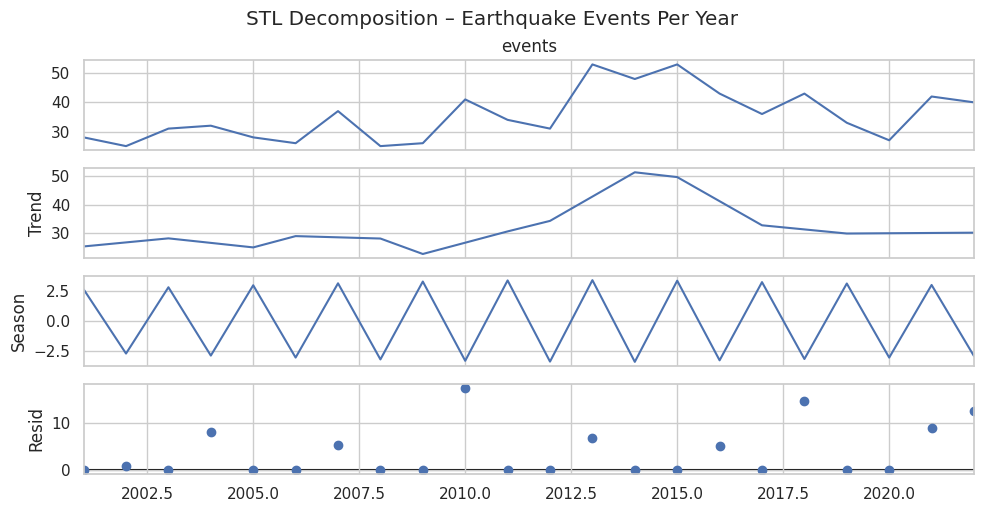

                               SARIMAX Results                                
Dep. Variable:                 events   No. Observations:                   22
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 -75.761
Date:                Mon, 03 Nov 2025   AIC                            159.522
Time:                        12:00:57   BIC                            163.886
Sample:                             0   HQIC                           160.550
                                 - 22                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         35.2090      4.452      7.908      0.000      26.482      43.935
ar.L1          0.7265      0.363      2.001      0.045       0.015       1.438
ma.L1         -0.3563      0.474     -0.752      0.4

/home/adarsh/.local/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/adarsh/.local/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/adarsh/.local/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/adarsh/.local/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is availa

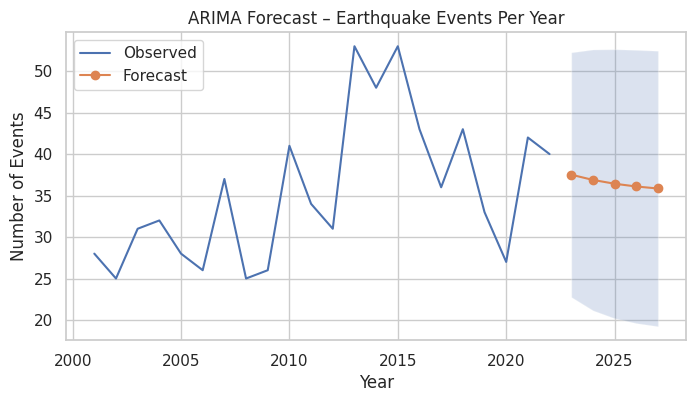

In [36]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

if 'Year' in df_proc_scaled.columns and df_proc_scaled['Year'].notnull().sum() > 0:
    ts_year = (df_proc_scaled.groupby('Year')
               .agg(events=('tsunami','count'),
                    tsunami_events=('tsunami','sum'))
               .sort_index())
    ts_year['tsunami_rate'] = ts_year['tsunami_events'] / ts_year['events']
    display(ts_year.head())

    if len(ts_year) >= 8:
        stl = STL(ts_year['events'], period=2, robust=True).fit()
        stl.plot()
        plt.suptitle("STL Decomposition – Earthquake Events Per Year", y=1.02)
        plt.show()

    if len(ts_year) >= 5:
        model = ARIMA(ts_year['events'], order=(1,0,1))
        results = model.fit()
        print(results.summary())

        forecast_steps = 5
        pred = results.get_forecast(steps=forecast_steps)
        mean_forecast = pred.predicted_mean
        conf_int = pred.conf_int()
        rmse = np.sqrt(mean_squared_error(ts_year['events'][-5:], mean_forecast[:5])) if len(ts_year)>=10 else None
        print(f"Forecast RMSE ≈ {rmse:.3f}" if rmse else "Forecast RMSE not computed (few years).")

        plt.figure(figsize=(8,4))
        plt.plot(ts_year.index, ts_year['events'], label='Observed')
        future_idx = list(range(int(ts_year.index.max())+1, int(ts_year.index.max())+1+forecast_steps))
        plt.plot(future_idx, mean_forecast, marker='o', label='Forecast')
        plt.fill_between(future_idx, conf_int.iloc[:,0], conf_int.iloc[:,1], alpha=0.2)
        plt.title("ARIMA Forecast – Earthquake Events Per Year")
        plt.xlabel("Year")
        plt.ylabel("Number of Events")
        plt.legend()
        plt.show()
else:
    print("No usable Year data for time-series forecasting.")
